### Import Packages

In [1]:
# Imports
# > Private packages
from image_io import *
from calculations import *
from consts import *
from plotting import *
# > Public packages
import torch

In [2]:
# Adjust Plot Resolution
# > If in IPython notebook utilize higher resolution 'retina' format
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('retina')
# > Adjust the resolution (dots-per-inch, DPI)
from matplotlib import rcParams
rcParams['figure.dpi'] = 100

### Create Polarization Vectors
Xenium provides coordinates in micrometers, these can be converted to pixels to match the pixel-resolution image data. Users can choose which combination of expression and morphology files will best suit their workflow.

In [3]:
from collections import defaultdict
from tqdm import tqdm
# Read in cell boundary data
df = pd.read_parquet('/PATH/TO/XENIUM/cell_boundaries.parquet')
# Map cell id to segmentation id
cell_ids = df['cell_id'].unique()
c2i = {x: i for i, x in enumerate(cell_ids)}
df['cell_id'] = df['cell_id'].map(c2i)
df = df[['vertex_x','vertex_y','cell_id']].values
# Convert micron to pixels
df[:, :2] /= 0.2125
# Instantiate tracking dictionary
segmentation_dict = defaultdict(list)
# Process all cell ids
prev_cell_id = None
for idx in tqdm(range(df.shape[0])):
    x, y, cell_id = df[idx, :]
    segmentation_dict[int(cell_id)].append([x, y])

100%|█████████████████████████████████████████████████████████████████████| 4054159/4054159 [00:08<00:00, 452894.40it/s]


In [4]:
# Path to the pyramid OME-TIFF
marker_file = '/PATH/TO/XENIUM/morphology_focus/morphology_focus_0003.ome.tif'
# Derive list of marker genes from the XML
print(f'Reading in TIF files from {marker_file}')
with tifffile.TiffFile(marker_file) as tif:
    ome_metadata = tif.ome_metadata
root = ET.fromstring(ome_metadata)
namespace = {'ome': 'http://www.openmicroscopy.org/Schemas/OME/2016-06'}
# Find all channel names
channel_names = []
for image in root.findall('ome:Image', namespace):
    for channel in image.find('ome:Pixels', namespace).findall('ome:Channel', namespace):
        name = channel.get('Name')
        channel_names.append(name)
# Retrieve full image
print(f'Loading OME-TIFF stack from: {marker_file}')
with tifffile.TiffFile(marker_file) as tif:
    marker_imstack = tif.asarray()
    num_layers, img_height, img_width = marker_imstack.shape
    print(f'Loaded image stack with {num_layers} layers, height: {img_height}, width: {img_width}')

Reading in TIF files from ../..//data/example_xenium_lung/morphology_focus/morphology_focus_0003.ome.tif
Loading OME-TIFF stack from: ../..//data/example_xenium_lung/morphology_focus/morphology_focus_0003.ome.tif


<tifffile.TiffFile 'morphology_focus_0003.ome.tif'> OME series cannot read multi-file pyramids


Loaded image stack with 4 layers, height: 17098, width: 51187


In [5]:
# Retrieve intensities (Y, X)
intensities = marker_imstack[channel_names.index('alphaSMA/Vimentin'), :, :]
del marker_imstack
# Set accelerator device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
intensities_acc = torch.tensor(intensities, device=device, dtype=torch.float32)
# Generate vector
vectors = generate_vector_field(segmentation_dict, intensities_acc, device)
vectors.to_csv('./VECTORS.csv')

In [6]:
# For most analyses, a subset of the data is enough to identify biologically relevant patterns
# ... this subsetting can be repeated multiple times or ROIs can be chosen (e.g. CD8+ T rich)
vectors = pd.read_csv('./VECTORS.csv', index_col=0)
mask = (vectors['x0'] >= 10000) & (vectors['x0'] < 20000)
mask = mask & (vectors['y0'] >= 7000) & (vectors['y0'] < 13000)
vectors = vectors.loc[mask].reset_index().iloc[:, 1:]

In [7]:
# Vectors are processed in chunks
chunk_size = 2500
start, end = 0, chunk_size
keys = ['smooth_u','smooth_v','smooth_magnitude','unit_u','unit_v']
vectors[keys] = np.nan
while start < vectors.shape[0]:
    # Subset for the relevant data
    mask = (vectors.index >= start) & (vectors.index < end)
    df = vectors.loc[mask]
    # Calculate distance matrix between each object
    dist_segment = cdist(df[['x0','y0']], df[['x0','y0']])
    dist_segment = pd.DataFrame(dist_segment, index=df.index, columns=df.index)
    # Only consider vectors above a minimum magnitude
    mask = df['magnitude'] >= MIN_VECTOR_MAGNITUDE
    df = df.loc[mask]
    # Smooth vectors by spatial distance
    df['smooth_u'] = spatial_smooth(df['xv'], SMOOTH_ITERS, dist_segment, SMOOTH_DIST_LIMIT_MICRONS / 0.2125)
    df['smooth_v'] = spatial_smooth(df['yv'], SMOOTH_ITERS, dist_segment, SMOOTH_DIST_LIMIT_MICRONS / 0.2125)
    # Normalize into unit vectors
    df['smooth_magnitude'] = np.linalg.norm(df[['smooth_u', 'smooth_v']], axis=1)
    df['unit_u'] = df['smooth_u'] / df['smooth_magnitude']
    df['unit_v'] = df['smooth_v'] / df['smooth_magnitude']
    # Add to the object
    vectors.loc[df.index, keys] = df[keys]
    # Proceed to next chunk
    start += chunk_size
    end += chunk_size
    if start % 10000 == 0: print(start)
vectors_save = vectors.copy()

10000
20000
30000


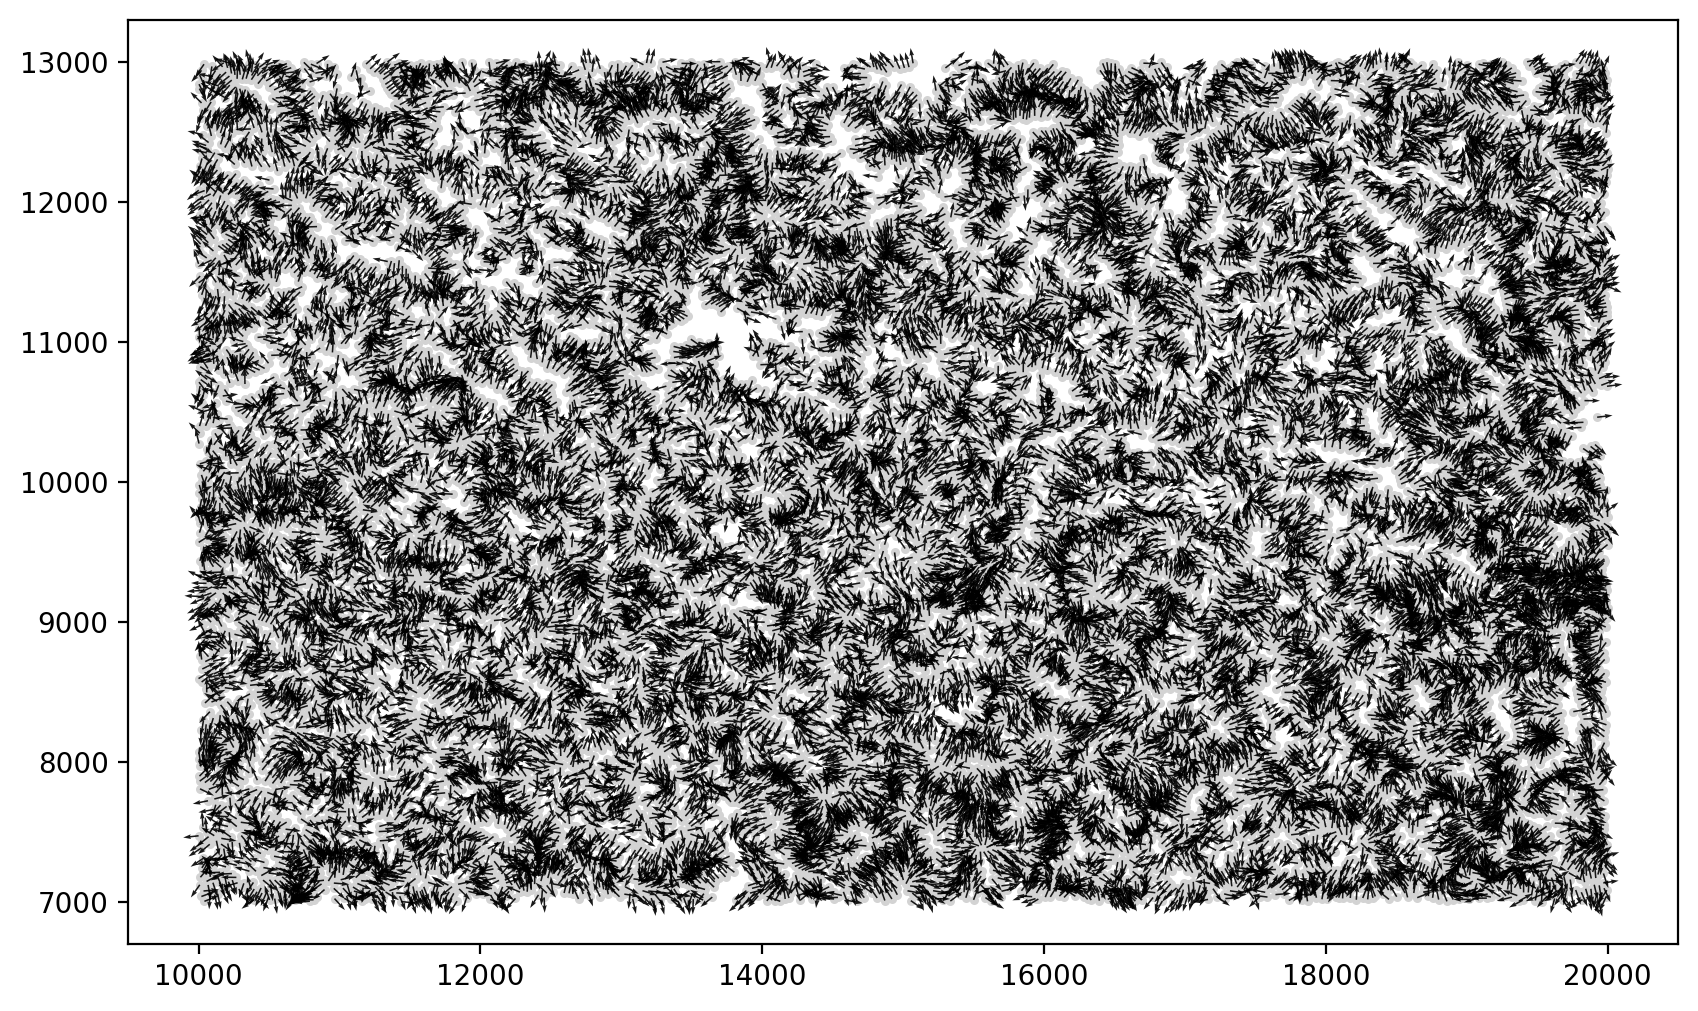

In [8]:
# Setup matplotlib figure
fig, ax = plt.subplots(figsize=[(vectors['x0'].max() - vectors['x0'].min()) / 1000,
                                (vectors['y0'].max() - vectors['y0'].min()) / 1000])
ax.grid(False)
# Plot quivers for the final polarization vectors
ax.scatter(vectors['x0'], vectors['y0'], color='lightgray', s=5)
ax.quiver(vectors['x0'], vectors['y0'], vectors['unit_u'], vectors['unit_v'],
          width=QUIVER_WIDTH * 0.5, scale=QUIVER_SCALE / 0.5, alpha=0.9)
xlim, ylim = ax.get_xlim(), ax.get_ylim()

### Integrate Vectors with Expression Data
Here, we present how the aforementioned vectors can be integrated with cell-resolution expression data to identify patterns associated with cell cytoskeleton polarizations. This entails typical single-cell processing, e.g. dimension reduction and clustering, followed by integration with the vectors (one could, for example, compute for cell types enriched with different polarization features).

In [10]:
import scanpy as sc
# Read in the vectors and expression data
vectors = pd.read_csv('./VECTORS.csv', index_col=0)
mask = (vectors['x0'] >= 10000) & (vectors['x0'] < 20000)
mask = mask & (vectors['y0'] >= 7000) & (vectors['y0'] < 13000)
adata = sc.read_10x_h5('/PATH/TO/XENIUM/cell_feature_matrix.h5')
# Add in vectors data
adata.obs['seg_id'] = adata.obs.index.map(c2i)
adata.obs[vectors.columns] = vectors.loc[adata.obs['seg_id']].values
# Add in spatial coordinates
adata.obsm['spatial'] = adata.obs[['x0','y0']].values
# Save raw counts
adata.layers['raw_counts'] = adata.X.copy()
# Normalize expression values
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
# Subset for the ROI
adata = adata[mask].copy()
vectors = vectors_save.copy()
adata.obs.index = vectors.index
sc.pp.filter_cells(adata, min_counts=1)

/home/dchen2/anaconda3/envs/base_py39/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:233: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))
/home/dchen2/anaconda3/envs/base_py39/lib/python3.9/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


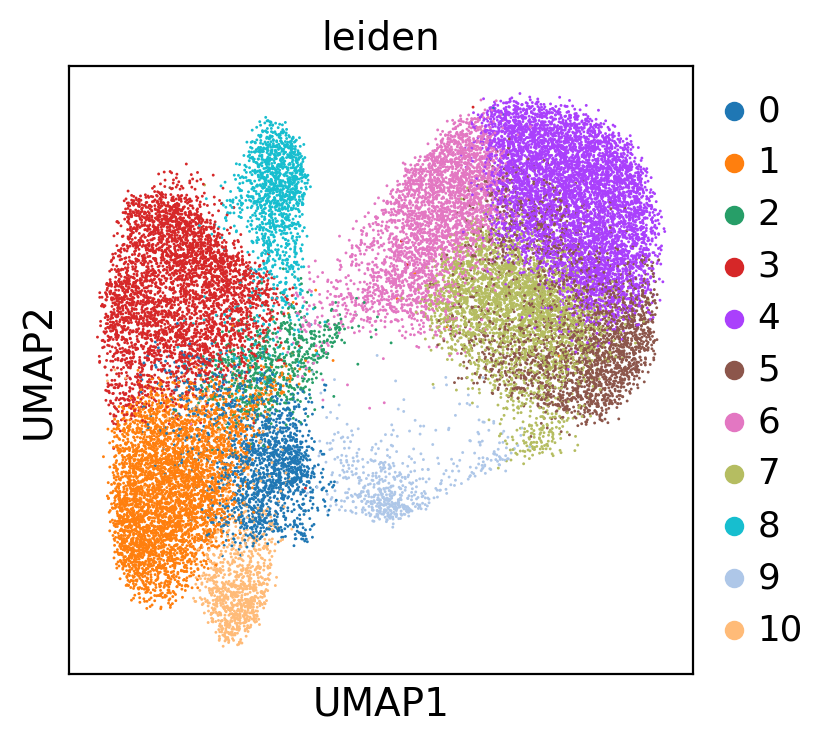

In [11]:
# Compute dimension reduction and unbiased clustering
sc.tl.pca(adata)
sc.pp.neighbors(adata, random_state=0)
sc.tl.umap(adata, random_state=0)
sc.tl.leiden(adata, flavor='igraph', n_iterations=2, random_state=0)
sc.pl.umap(adata, color=['leiden'])
# Integrate vectors onto the data
smoothed_vectors = vectors.copy()
vectors = vectors.iloc[:, :6].copy()
adata.obs[smoothed_vectors.columns] = smoothed_vectors.loc[adata.obs.index.astype(int)].values

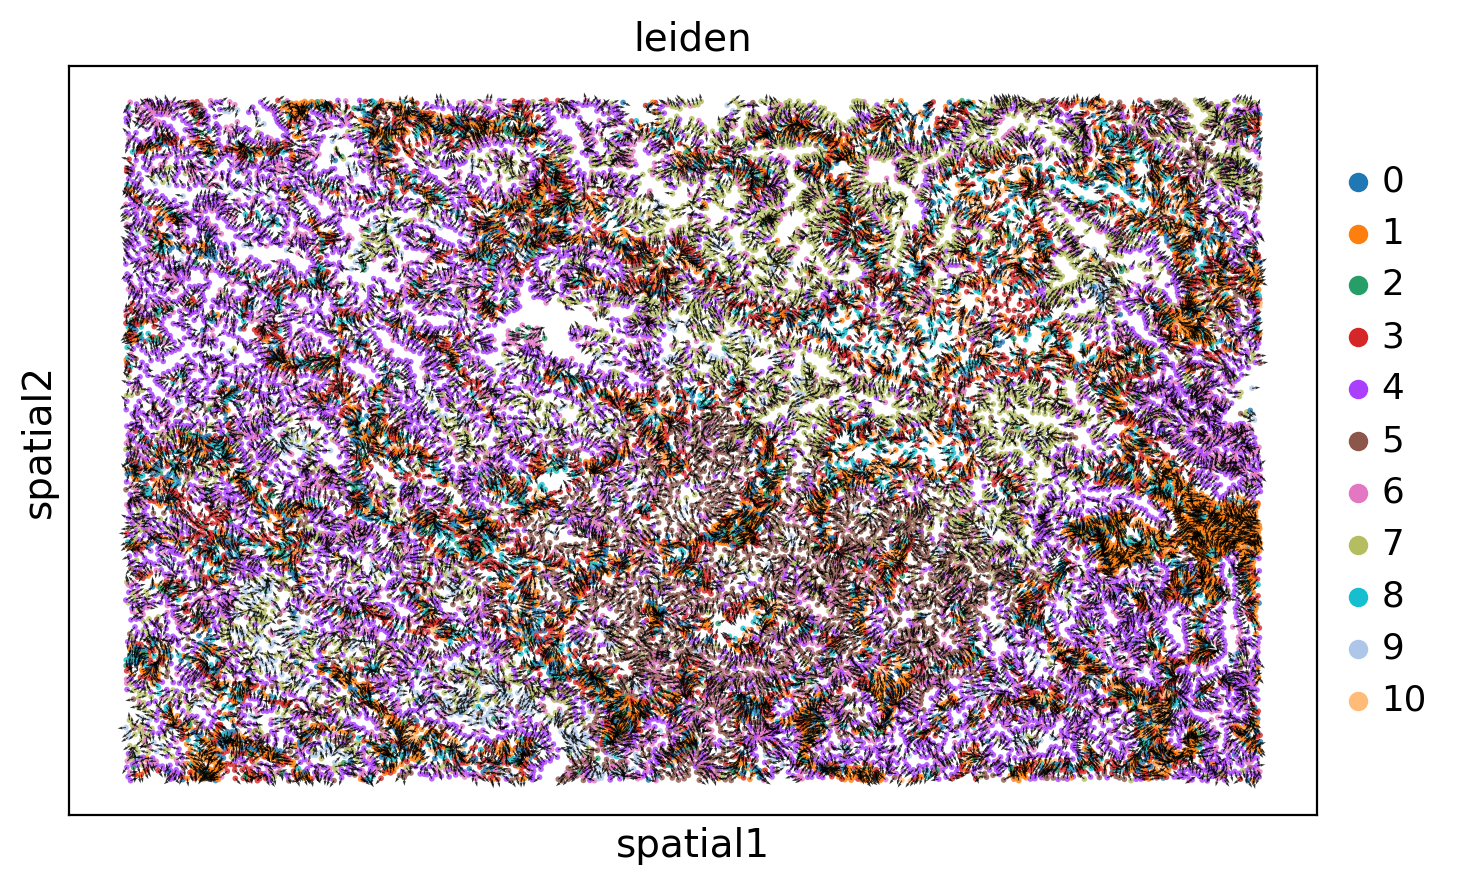

In [12]:
# Project expression clusters onto the polarization angles in spatial space
fig, ax = plt.subplots(figsize=[8, 8])
ax = sc.pl.spatial(adata, spot_size=0, show=False, ax=ax)
ax = sc.pl.spatial(adata, spot_size=50, ax=ax[0], color=['leiden'], show=False, alpha=0.8)[0]
ax.quiver(adata.obs['x0'], adata.obs['y0'], adata.obs['unit_u'], adata.obs['unit_v'],
          width=QUIVER_WIDTH * 0.4, scale=QUIVER_SCALE * 3, alpha=0.8)

### Computation of "Streams"
CytoRipple angles can then be utilized to calculate "streams", that is head-to-tail cells that are polarized towards the same direction. This can be used to identify common paths of cytoskeleton polarization, and thus, potential motility, within tissues.

In [13]:
# Compute the polarization angles
smoothed_vectors['angle'] = np.arctan(smoothed_vectors['unit_u'] / smoothed_vectors['unit_v'])
smoothed_vectors.loc[smoothed_vectors['unit_u'] < 0, 'angle'] += np.pi
smoothed_vectors['angle'] = (smoothed_vectors['angle'] + 2 * np.pi) % (2 * np.pi)
angles = smoothed_vectors['angle']
angles.index = angles.index.astype(str)
adata.obs['angle'] = angles.loc[adata.obs.index].values
# Compute all distances to be used
dist = cdist(adata.obsm['spatial'], adata.obsm['spatial']) * 0.2125
dist = pd.DataFrame(dist, index=adata.obs.index, columns=adata.obs.index)

In [1]:
# Define a method to compute the next step in a stream
def iter_angle(src_x, src_y, src_angle):
    # Compute distance
    dist_to_idx = cdist(adata.obsm['spatial'], [[src_x, src_y]])[:, 0]
    close_idxs = adata.obs.index[dist_to_idx < max_radius]
    close_idxs = close_idxs[close_idxs != idx]
    close_angles = adata.obs.loc[close_idxs, 'angle'].dropna()
    
    # Angles may be computed in differences from clock or counter clock wise
    # Only keep indices within 45 degrees (can be adjusted below)
    angle_diffs1 = (close_angles - src_angle).abs()
    angle_diffs2 = (close_angles - (src_angle + 2 * np.pi)).abs()
    angle_diffs = pd.concat([angle_diffs2, angle_diffs1], axis=1).min(axis=1)
    valid_idxs = angle_diffs.index[angle_diffs < view_angle]
    
    # Then the cells themselves must be within 45 degrees of the original cell
    xdiff = adata[valid_idxs].obsm['spatial'][:, 0] - src_x
    ydiff = adata[valid_idxs].obsm['spatial'][:, 1] - src_y
    angle_to_src = pd.Series((np.arctan(ydiff / xdiff) + 2 * np.pi) % (2 * np.pi), index=valid_idxs)
    angle_to_src[xdiff < 0] += np.pi
    angle_diffs1 = (angle_to_src - src_angle).abs()
    angle_diffs2 = (angle_to_src - (src_angle + 2 * np.pi)).abs()
    angle_diffs_to_src = pd.concat([angle_diffs2, angle_diffs1], axis=1).min(axis=1)
    next_idxs = valid_idxs[angle_diffs_to_src < view_angle]
    if len(next_idxs) == 0: return
        
    return x, y, angle, next_idxs

In [15]:
import warnings
warnings.filterwarnings('ignore')
# Define parameters of the stream calculation
max_radius = 90
view_angle = np.pi / 4
streams = {}
# Loop through each cell in the tissue
for idx in adata.obs.index:
    # Intially gather data (spatial position and angle)
    src_x = adata[idx].obsm['spatial'][:, 0][0]
    src_y = adata[idx].obsm['spatial'][:, 1][0]
    src_angle = adata.obs.loc[idx, 'angle']
    # Instantiate a tracker of next steps
    next_idxs_list = []
    # Maximally walk 25 steps
    for _ in range(25):  # This can be extended
        try:
            prev_x, prev_y = src_x, src_y
            src_x, src_y, src_angle, next_idxs = iter_angle(src_x, src_y, src_angle)
            next_idxs_list.append(next_idxs)
        except:
            break
    if len(next_idxs_list) < 5:  # Users can decide what is the minimum number of steps
        continue
    streams[idx] = next_idxs_list
# Calculate positions (centroids) for each step
stream_pos = {k: [adata[el].obsm['spatial'].mean(0) for el in els] for k, els in streams.items()}

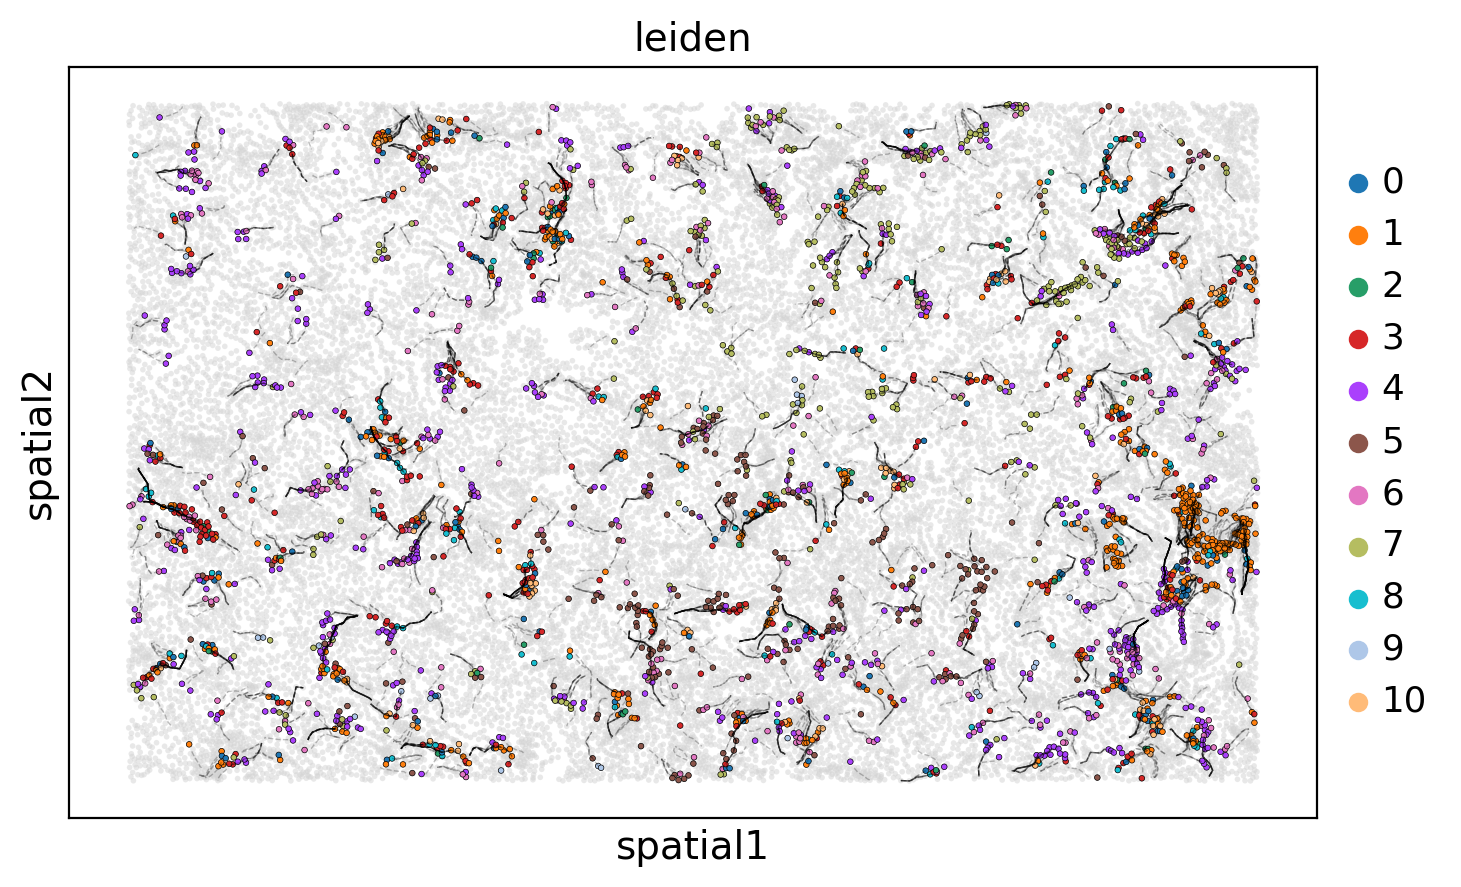

In [16]:
import scanpy as sc
# Plot on the streams with their associated cells
fig, ax = plt.subplots(figsize=[8, 8])
_ = ax.grid(False)
ax = sc.pl.spatial(adata, spot_size=50, show=False, ax=ax, alpha=0.5)[0]
ax = sc.pl.spatial(adata[list(streams.keys())], spot_size=50, ax=ax, color=['leiden'],
                   show=False, alpha=1, edgecolor='k', linewidth=0.25)[0]
for v in stream_pos.values():
    v = np.array(v)
    ax.plot(v[:, 0], v[:, 1], color='k', alpha=0.25, lw=0.5, linestyle='--')

### Identifying Patterns of "Streams"
Here, we show how one can integrate streams onto a common embedding by defining stream-to-stream distance as the difference in expression between a given step's past-present to another step's present-future (i.e. if similar, then it implies that the given step may be "related" or similar, in expression space, to the queried step and thus placed closer together).

In [17]:
# Assemble expression across steps of all streams
timepoints = ['PAST','PRESENT','FUTURE']
exprs, names, pos = [], [], []
for k, next_idxs_list in streams.items()):
    # Skip streams with few data
    if len(next_idxs_list) < 3:
        continue
    n_steps = len(next_idxs_list) - 3 + 1
    for start in range(n_steps):
        # Gather data and create a name
        idxs_list = next_idxs_list[start:start+3]
        name = ';'.join([','.join(els) for els in idxs_list])
        # Skip if already identified
        if name in names:
            continue
        # Retrieve expression data
        expr = []
        for idxs, timepoint in zip(idxs_list, timepoints):
            expr.append(pd.Series(adata[idxs].X.mean(0).A1, index=adata.var.index + ':' + timepoint))
        expr = pd.concat(expr, axis=0)
        expr.name = name
        exprs.append(expr)
        names.append(name)
        # Get the spatial position of the center
        pos.append(adata[idxs_list[1]].obsm['spatial'].mean(0))
expr = pd.concat(exprs, axis=1).T

In [18]:
from sklearn.neighbors import kneighbors_graph
import phate
# Concatenate all of the expression profiles
expr = pd.concat(exprs, axis=1).T
X = cdist(expr.iloc[:, :-expr.shape[1] // 3].values, expr.iloc[:, expr.shape[1] // 3:].values)
# Compute kNN graph and PHATE projection via past-present - present-future distances
knn = kneighbors_graph(X, n_neighbors=15+1, include_self=True, metric='euclidean', mode='connectivity')
phate_operator = phate.PHATE(n_jobs=20, random_state=0, knn_dist='precomputed_affinity', n_landmark=2000)
stream_phate = phate_operator.fit_transform(knn)
# Instantiate anndata object based on the trajectory expression profiles
import anndata as ad
edata = ad.AnnData(expr)
edata.obsm['X_phate'] = stream_phate

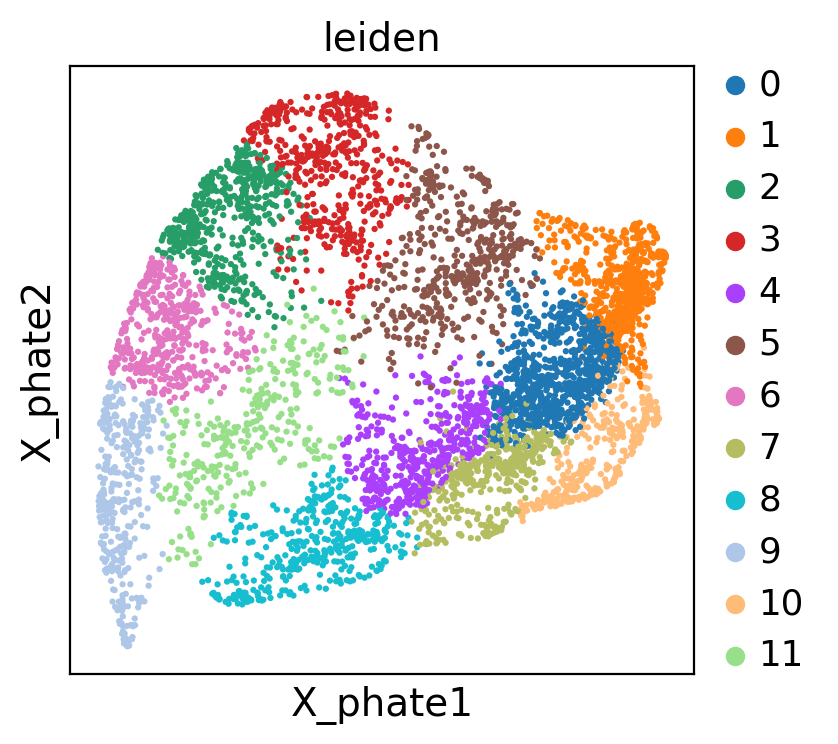

In [19]:
import igraph as ig
import leidenalg as la
# Perform leiden clustering on kNN graph (symmetrized)
def sparse_to_igraph(sparse_mx):
    sparse_mx = sparse_mx.tocoo()
    edges = list(zip(sparse_mx.row, sparse_mx.col))
    weights = sparse_mx.data
    g = ig.Graph(n=sparse_mx.shape[0], edges=edges, directed=False)
    g.es['weight'] = weights
    return g
knn_sym = 0.5 * (knn + knn.T)
g = sparse_to_igraph(knn_sym)
partition = la.find_partition(g, la.RBConfigurationVertexPartition, weights=g.es['weight'],
                              seed=0, resolution_parameter=0.8)
edata.obs['leiden'] = pd.Series(partition.membership, index=edata.obs.index).astype(str)
# Each dot represents a step in a stream and they are embedded based on their expression distance
sc.pl.embedding(edata, basis='X_phate', color=['leiden'])

Here, we show how we can then calculate how biomarkers (e.g. RNA or protein) vary along streams. To provide a linear distance along streams, we place trajectory steps via their distance in expression space, for example, between the origin and termini of identified streams (this can be subsetted for a given cluster to define cluster-specific patterns).

In [20]:
# Derive the list of paths from the streams
paths = []
for k, next_idxs_list in tqdm(streams.items()):
    # Skip if there are not enough steps
    if len(next_idxs_list) < 3:
        continue
    n_steps = len(next_idxs_list) - 3 + 1
    names = []
    for start in range(n_steps):
        # gather data and create a name
        idxs_list = next_idxs_list[start:start+3]
        name = ';'.join([','.join(els) for els in idxs_list])
        names.append(name)
    paths.append(names)
    
# Retrieve the origin and termini from the paths
origins_idxs, termini_idxs = [], []
for path in tqdm(paths):
    origins_idxs.append(path[0])
    termini_idxs.append(path[-1])
mask_o = edata.obs.index.intersection(origins_idxs)
mask_t = edata.obs.index.intersection(termini_idxs)

100%|██████████████████████████████████████████████████████████████████████████| 2758/2758 [00:00<00:00, 2014960.88it/s]


In [21]:
# Compute distances between the points
expr = pd.DataFrame(edata.X, index=edata.obs.index, columns=edata.var.index)
dist_to_o = cdist(expr.loc[mask_o].iloc[:, :-expr.shape[1] // 3].values, expr.iloc[:, expr.shape[1] // 3:].values)
dist_to_t = cdist(expr.loc[mask_t].iloc[:, :-expr.shape[1] // 3].values, expr.iloc[:, expr.shape[1] // 3:].values)
avg_dist_to_o = dist_to_o.mean(0)
avg_dist_to_t = dist_to_t.mean(0)
dist_o_to_t = avg_dist_to_o - avg_dist_to_t
# Subset for expression of steps at the given step (i.e. not past or future expression)
expr = expr[expr.columns[expr.columns.str.endswith(':PRESENT')]].copy()
expr.columns = expr.columns.str.replace(':PRESENT','')

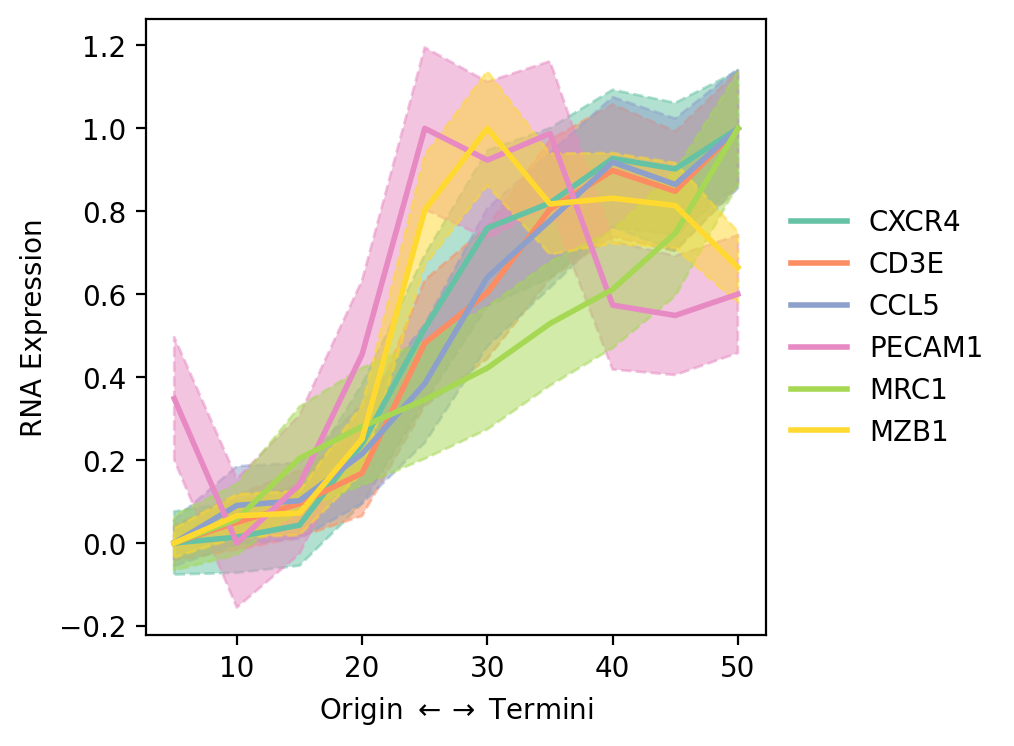

In [22]:
import seaborn as sns
# Present example 
markers = ['CXCR4','CD3E','CCL5','PECAM1','MRC1','MZB1']
fig, ax = plt.subplots(figsize=[4, 4])
_ = ax.grid(False)
colors = sns.color_palette('Set2', len(markers)).as_hex()
for marker, color in zip(markers, colors):
    xs, ys = dist_o_to_t, expr[marker]
    xl, yl, yci = [], [], []
    step_size = 10; max_val = round(100 / step_size)
    for step in range(1, max_val+1):
        vmin = np.percentile(xs, (step-1)*step_size)
        if step == 1: vmin = xs.min()
        vmax = np.percentile(xs, step*step_size)
        if step == max_val: vmax = xs.max() + 1
        mask = (xs >= vmin) & (xs < vmax)
        xl.append(step*5)
        yl.append(ys[mask].mean())
        yci.append(ys[mask].std()*1.96/np.sqrt(sum(mask)))
    yl = np.array(yl)
    yl = yl - yl.min()
    yl = yl / yl.max()
    # plot the values
    _ = ax.plot(xl, yl, color=color, lw=2, zorder=1, linestyle='-', label=marker.split(':')[0])
    _ = ax.fill_between(xl, yl+yci, yl-yci, color=color, zorder=0, lw=1, linestyle='--', alpha=0.5)
_ = ax.set(xlabel='Origin $\leftarrow \\rightarrow$ Termini', ylabel='RNA Expression')
_ = ax.legend(bbox_to_anchor=(1, .5), bbox_transform=ax.transAxes, loc='center left', frameon=False)